# 05 - Train model (ResNet18)

Trains a **ResNet18** classifier on the `data/splits/` set produced by step 04: frozen ImageNet
backbone + a fresh classifier head, class-weighted loss, early stopping. Reports synthetic-test
accuracy, a confusion matrix, and a **zero-shot CLIP** baseline for comparison.

Adapted from Avital's notebook: paths come from `utils.py` (no Colab/Drive); class labels come from
the folders. An optional full fine-tuning pass and an optional real-CCTV evaluation are included.

## Install + imports

In [1]:
# !pip install torch torchvision scikit-learn transformers matplotlib
import os
# --- choose the GPU here (before torch); change "0" + restart kernel to switch ---
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
import numpy as np
import torch, torch.nn as nn
from torchvision import datasets, transforms
from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

import sys
from pathlib import Path
# Make utils.py importable whether launched from code/ or the Project Main Folder (workspace root).
for _cand in (Path.cwd(), Path.cwd() / "code"):
    if (_cand / "utils.py").exists() and str(_cand) not in sys.path:
        sys.path.insert(0, str(_cand)); break
import utils

torch.manual_seed(utils.SEED); np.random.seed(utils.SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# --- Experiment tracking (Weights & Biases) ---
# Active ONLY if WANDB_API_KEY is set in the environment (e.g. via shlomi/secrets.env in the
# container), so the notebook runs unchanged with or without tracking. No keys live in the notebook.
import os
USE_WANDB = True
if USE_WANDB:
    import wandb
    wandb.login()                      # reads WANDB_API_KEY from the environment
def wlog(d):
    if USE_WANDB:
        wandb.log(d)
print("W&B logging:", "ON" if USE_WANDB else "off (set WANDB_API_KEY to enable)")

device: cuda


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/benshise/.netrc.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


W&B logging: ON


## Paths

In [2]:
train_dir = utils.SPLITS_DIR / "train"
val_dir   = utils.SPLITS_DIR / "val"
test_dir  = utils.SPLITS_DIR / "test"
real_test_dir = utils.DATA_DIR / "real_test"     # optional (created by step 04 if you had real labels)
utils.RESULTS_DIR.mkdir(parents=True, exist_ok=True)

## Transforms

Train-time augmentation on top of the baked-in CCTV degradation; eval is just resize+normalize.

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(8),
    # transforms.RandomPerspective(distortion_scale=0.2, p=0.4),
    # transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    # transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.2)),
    transforms.ToTensor(),
    # transforms.Lambda(lambda x: x + 0.03 * torch.randn_like(x)),
    transforms.Normalize([0.5]*3, [0.5]*3),
])
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

## Preview: what `train_transform` does (live per-epoch augmentation)

This is the runtime augmentation applied to each (already-degraded) image **every epoch** - it is NOT
saved to disk. Run this cell to SEE it, then tune the transform above and re-run. (To preview without
running the whole notebook:  `python shlomi/preview_train_transform.py`.)

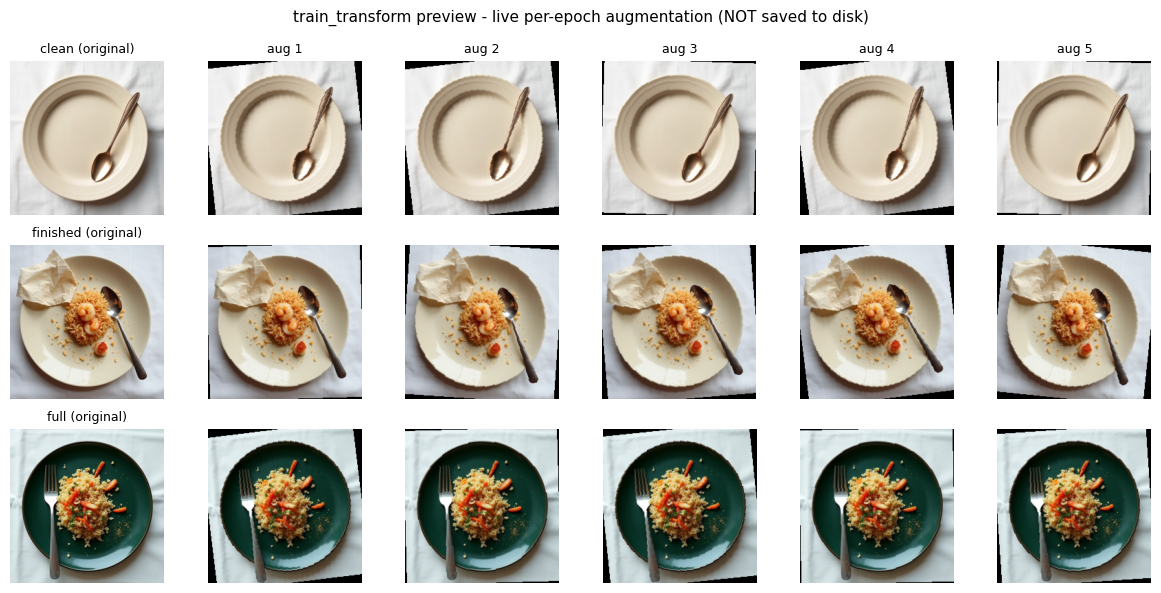

In [4]:
import matplotlib.pyplot as plt
from PIL import Image as _Image

def _unnorm(t):                       # invert Normalize([0.5]*3,[0.5]*3) -> [0,1] for display
    return (t * 0.5 + 0.5).clamp(0, 1).permute(1, 2, 0).numpy()

_classes = sorted(d.name for d in utils.CLEAN_DIR.iterdir() if d.is_dir())
_K = 5                                 # random augmentations shown per image
_fig, _ax = plt.subplots(len(_classes), _K + 1, figsize=(2 * (_K + 1), 2 * len(_classes)), squeeze=False)
for _r, _cls in enumerate(_classes):
    _f = sorted((utils.CLEAN_DIR / _cls).glob("*"))[0]
    _img = _Image.open(_f).convert("RGB")
    _ax[_r][0].imshow(_img.resize((224, 224))); _ax[_r][0].axis("off")
    _ax[_r][0].set_title(f"{_cls} (original)", fontsize=9)
    for _k in range(_K):
        _ax[_r][_k + 1].imshow(_unnorm(train_transform(_img))); _ax[_r][_k + 1].axis("off")
        if _r == 0: _ax[_r][_k + 1].set_title(f"aug {_k + 1}", fontsize=9)
_fig.suptitle("train_transform preview - live per-epoch augmentation (NOT saved to disk)", fontsize=11)
plt.tight_layout()
utils.RESULTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(utils.RESULTS_DIR / "train_transform_preview.png", dpi=110, bbox_inches="tight")
plt.show()

## Datasets + loaders

In [5]:
train_dataset = datasets.ImageFolder(str(train_dir), transform=train_transform)
val_dataset   = datasets.ImageFolder(str(val_dir),   transform=test_transform)
test_dataset  = datasets.ImageFolder(str(test_dir),  transform=test_transform)
CLASSES = train_dataset.classes
print("classes:", CLASSES)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=4)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=4)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=4)

classes: ['clean', 'finished', 'full']


## Model: ResNet18, frozen backbone + new head

In [6]:
model = resnet18(weights=ResNet18_Weights.DEFAULT)
for p in model.parameters():
    p.requires_grad = False                      # feature-extraction baseline
model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
model = model.to(device)

## Loss (class-weighted) + optimizer

In [7]:
from collections import Counter
counts = Counter(lbl for _, lbl in train_dataset.samples)
total = sum(counts.values())
weights = torch.tensor([total / counts[i] for i in range(len(CLASSES))], dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)

## Train / eval helpers

In [8]:
def run_epoch(model, loader, train, optimizer=None):
    model.train() if train else model.eval()
    total_loss = correct = total = 0
    torch.set_grad_enabled(train)
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        if train: optimizer.zero_grad()
        out = model(x); loss = criterion(out, y)
        if train: loss.backward(); optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct += (out.argmax(1) == y).sum().item(); total += y.size(0)
    torch.set_grad_enabled(True)
    return total_loss / total, correct / total

## Train (frozen backbone) with early stopping

In [9]:
EPOCHS, PATIENCE = 30, 7
best_val, counter = 0.0, 0
hist = {"tr_loss": [], "tr_acc": [], "va_loss": [], "va_acc": []}
ckpt = utils.RESULTS_DIR / "resnet18_frozen_best.pth"
if USE_WANDB:
    wandb.init(project=os.environ.get("WANDB_PROJECT", "plate-classification"),
               name=os.environ.get("WANDB_RUN_NAME", "shlomi_resnet18_frozen"),
               config={"epochs": EPOCHS, "patience": PATIENCE, "lr": 1e-4,
                       "model": "resnet18_frozen", "classes": CLASSES})

for epoch in range(EPOCHS):
    tr_loss, tr_acc = run_epoch(model, train_loader, True, optimizer)
    va_loss, va_acc = run_epoch(model, val_loader, False)
    te_loss, te_acc = run_epoch(model, test_loader, False)   # eval test each epoch -> a curve (val still drives early-stop)
    for k, v in zip(hist, (tr_loss, tr_acc, va_loss, va_acc)): hist[k].append(v)
    print(f"epoch {epoch+1:02d} | train {tr_acc:.3f}/{tr_loss:.3f} | val {va_acc:.3f}/{va_loss:.3f} | test {te_acc:.3f}")
    wlog({"train_loss": tr_loss, "train_acc": tr_acc, "val_loss": va_loss, "val_acc": va_acc, "test_loss": te_loss, "test_acc": te_acc, "epoch": epoch + 1})
    if va_acc > best_val:
        best_val, counter = va_acc, 0
        torch.save(model.state_dict(), ckpt); print("  saved best")
    else:
        counter += 1
        if counter >= PATIENCE:
            print("  early stopping"); break
model.load_state_dict(torch.load(ckpt)); print("loaded best (val acc %.3f)" % best_val)

wandb: Currently logged in as: sghlomi (sghlomi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


epoch 01 | train 0.516/0.997 | val 0.604/0.886 | test 0.584
  saved best
epoch 02 | train 0.690/0.802 | val 0.744/0.721 | test 0.721
  saved best
epoch 03 | train 0.757/0.680 | val 0.787/0.637 | test 0.765
  saved best
epoch 04 | train 0.779/0.613 | val 0.806/0.575 | test 0.799
  saved best
epoch 05 | train 0.802/0.563 | val 0.823/0.531 | test 0.817
  saved best
epoch 06 | train 0.816/0.527 | val 0.835/0.500 | test 0.834
  saved best
epoch 07 | train 0.830/0.493 | val 0.835/0.481 | test 0.837
epoch 08 | train 0.832/0.473 | val 0.835/0.463 | test 0.847
epoch 09 | train 0.840/0.453 | val 0.838/0.451 | test 0.850
  saved best
epoch 10 | train 0.843/0.438 | val 0.845/0.434 | test 0.859
  saved best
epoch 11 | train 0.847/0.428 | val 0.846/0.423 | test 0.859
  saved best
epoch 12 | train 0.852/0.413 | val 0.846/0.413 | test 0.860
epoch 13 | train 0.857/0.405 | val 0.845/0.411 | test 0.854
epoch 14 | train 0.853/0.403 | val 0.851/0.400 | test 0.868
  saved best
epoch 15 | train 0.863/0.389 |

/tmp/ipykernel_1621683/40374681.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt)); print("loaded best (val acc %.3f)" % best_val)


loaded best (val acc 0.868)


## Training curves

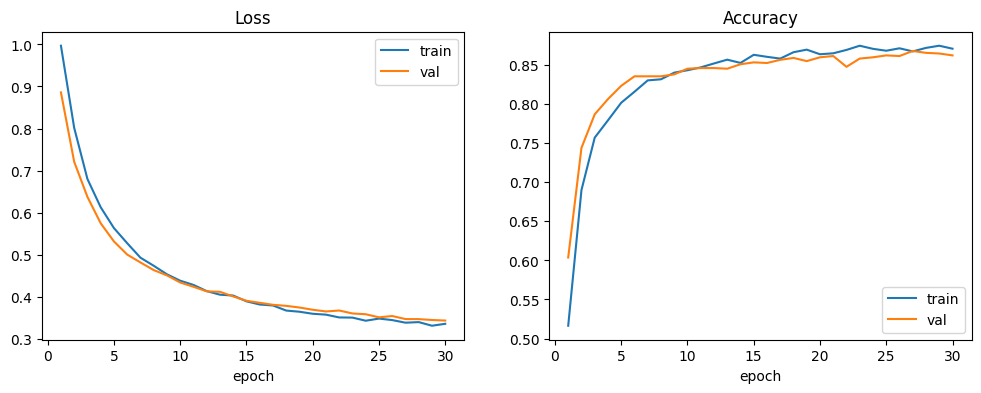

In [10]:
ep = range(1, len(hist["tr_loss"]) + 1)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1); plt.plot(ep, hist["tr_loss"], label="train"); plt.plot(ep, hist["va_loss"], label="val")
plt.title("Loss"); plt.xlabel("epoch"); plt.legend()
plt.subplot(1, 2, 2); plt.plot(ep, hist["tr_acc"], label="train"); plt.plot(ep, hist["va_acc"], label="val")
plt.title("Accuracy"); plt.xlabel("epoch"); plt.legend(); plt.show()

## Synthetic test + confusion matrix + binary decision accuracy

Synthetic test: acc 0.888 | loss 0.320
macro-F1: 0.889


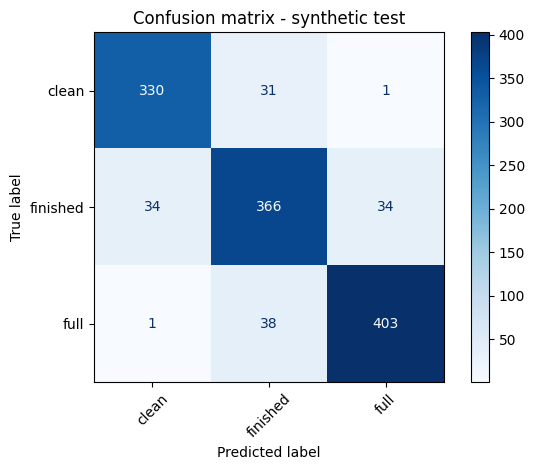

Binary (clear/do_not_clear) acc: 0.889


In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score

def predict(model, loader):
    model.eval(); ys, ps = [], []
    with torch.no_grad():
        for x, y in loader:
            ps.extend(model(x.to(device)).argmax(1).cpu().numpy()); ys.extend(y.numpy())
    return np.array(ys), np.array(ps)

test_loss, test_acc = run_epoch(model, test_loader, False)
print(f"Synthetic test: acc {test_acc:.3f} | loss {test_loss:.3f}")

y_true, y_pred = predict(model, test_loader)
print("macro-F1:", round(f1_score(y_true, y_pred, average='macro'), 3))
wlog({"macro_f1": float(f1_score(y_true, y_pred, average="macro"))})   # test_acc/test_loss are per-epoch curves now
if USE_WANDB:
    wandb.log({"confusion_matrix": wandb.plot.confusion_matrix(probs=None, y_true=y_true, preds=y_pred, class_names=CLASSES)})
ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred), display_labels=CLASSES).plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion matrix - synthetic test"); plt.tight_layout(); plt.show()

# Binary clear / do-not-clear accuracy (the actual deployment metric).
to_bin = {i: utils.to_binary(c) for i, c in enumerate(CLASSES)}
bt = [to_bin[t] for t in y_true]; bp = [to_bin[p] for p in y_pred]
print("Binary (clear/do_not_clear) acc:", round(np.mean(np.array(bt) == np.array(bp)), 3))

## Zero-shot CLIP baseline

In [12]:
from transformers import CLIPModel, CLIPProcessor
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32", use_safetensors=True).to(device)
clip_proc  = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

CLASS_DESC = {
    "clean": "a pristine clean empty plate with no food",
    "finished": "a used plate after a meal, eaten bare with only crumbs, sauce smears or a few small food scraps left",
    "full": "a full plate with a complete serving of food",
}
labels_text = [CLASS_DESC.get(c, f"a plate, category {c}") for c in CLASSES]

def clip_eval(loader):
    correct = total = 0
    with torch.no_grad():
        for x, y in loader:
            for i in range(len(x)):
                img = transforms.ToPILImage()(x[i] * 0.5 + 0.5)   # un-normalize for CLIP
                inp = clip_proc(text=labels_text, images=img, return_tensors="pt", padding=True).to(device)
                pred = clip_model(**inp).logits_per_image.softmax(1).argmax().item()
                correct += int(pred == y[i].item()); total += 1
    return correct / total

clip_acc = round(clip_eval(test_loader), 3)
print("CLIP zero-shot (synthetic test):", clip_acc)
wlog({"clip_acc": clip_acc})

/home/benshise/my_new_project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


CLIP zero-shot (synthetic test): 0.612


## (Optional) Fine-tuning - PARTIAL (layer4 + head)

Unfreeze only the **last residual block (`layer4`) + the classifier head** and train at a low LR with
stronger weight decay. Full-backbone fine-tuning overfits this small synthetic set (train ~0.99 while
val stalls and val-loss rises); partial fine-tuning adapts the high-level features while keeping the
general early layers frozen. Report this vs the frozen linear-probe baseline.

In [13]:
RUN_FINETUNE = True    # also fine-tune. PARTIAL by default (layer4 + head) to avoid overfitting.
FT_EPOCHS, FT_PATIENCE = 15, 4
if RUN_FINETUNE:
    # Anti-overfit: unfreeze ONLY the last residual block (layer4) + the head - NOT the whole backbone.
    # Full-backbone FT memorized this small synthetic set (train ~0.99 / val ~0.95, val loss rising).
    # Keeping layer1-3 frozen (general features) + stronger weight decay + earlier stopping curbs it.
    for p in model.parameters(): p.requires_grad = False
    for p in model.layer4.parameters(): p.requires_grad = True
    for p in model.fc.parameters(): p.requires_grad = True
    optimizer = torch.optim.Adam([p for p in model.parameters() if p.requires_grad],
                                 lr=1e-5, weight_decay=1e-3)        # stronger L2 (was 1e-4)
    best_val, counter = 0.0, 0
    ft_hist = {"tr_loss": [], "tr_acc": [], "va_loss": [], "va_acc": []}
    ckpt_ft = utils.RESULTS_DIR / "resnet18_finetuned_best.pth"

    if USE_WANDB:                                   # log FT as its OWN W&B run (same metric names as LP -> overlay)
        wandb.finish()                              # close the linear-probe run first
        wandb.init(project=os.environ.get("WANDB_PROJECT", "plate-classification"),
                   name="shlomi_resnet18_finetuned",
                   config={"epochs": FT_EPOCHS, "patience": FT_PATIENCE, "lr": 1e-5,
                           "weight_decay": 1e-3, "unfreeze": "layer4+fc",
                           "model": "resnet18_finetuned", "classes": CLASSES})
    for epoch in range(FT_EPOCHS):
        tr_loss, tr_acc = run_epoch(model, train_loader, True, optimizer)
        va_loss, va_acc = run_epoch(model, val_loader, False)
        te_loss, te_acc = run_epoch(model, test_loader, False)   # eval test each epoch -> a curve
        for k, v in zip(ft_hist, (tr_loss, tr_acc, va_loss, va_acc)): ft_hist[k].append(v)
        print(f"[FT] epoch {epoch+1:02d} | train {tr_acc:.3f}/{tr_loss:.3f} | val {va_acc:.3f}/{va_loss:.3f} | test {te_acc:.3f}")
        wlog({"train_loss": tr_loss, "train_acc": tr_acc, "val_loss": va_loss, "val_acc": va_acc, "test_loss": te_loss, "test_acc": te_acc, "epoch": epoch + 1})
        if va_acc > best_val:
            best_val, counter = va_acc, 0
            torch.save(model.state_dict(), ckpt_ft); print("  saved best (ft)")
        else:
            counter += 1
            if counter >= FT_PATIENCE:
                print("  early stopping (ft)"); break
    model.load_state_dict(torch.load(ckpt_ft)); print("loaded best ft (val acc %.3f)" % best_val)
else:
    print("RUN_FINETUNE is False - skipping fine-tuning.")

clip_acc,▁
epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
macro_f1,▁
test_acc,▁▄▅▆▆▇▇▇▇▇▇▇▇▇█▇▇▇████████████
test_loss,█▆▅▄▄▃▃▃▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
train_acc,▁▄▆▆▇▇▇▇▇▇▇███████████████████
train_loss,█▆▅▄▃▃▃▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
val_acc,▁▅▆▆▇▇▇▇▇▇▇▇▇████████▇████████
val_loss,█▆▅▄▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
clip_acc,0.612
epoch,30


[FT] epoch 01 | train 0.887/0.287 | val 0.896/0.268 | test 0.904
  saved best (ft)
[FT] epoch 02 | train 0.917/0.222 | val 0.904/0.238 | test 0.923
  saved best (ft)
[FT] epoch 03 | train 0.929/0.186 | val 0.917/0.217 | test 0.931
  saved best (ft)
[FT] epoch 04 | train 0.942/0.155 | val 0.916/0.202 | test 0.933
[FT] epoch 05 | train 0.954/0.128 | val 0.926/0.188 | test 0.941
  saved best (ft)
[FT] epoch 06 | train 0.960/0.114 | val 0.931/0.178 | test 0.946
  saved best (ft)
[FT] epoch 07 | train 0.965/0.099 | val 0.935/0.173 | test 0.947
  saved best (ft)
[FT] epoch 08 | train 0.972/0.088 | val 0.938/0.167 | test 0.948
  saved best (ft)
[FT] epoch 09 | train 0.976/0.075 | val 0.942/0.159 | test 0.949
  saved best (ft)
[FT] epoch 10 | train 0.980/0.066 | val 0.948/0.148 | test 0.950
  saved best (ft)
[FT] epoch 11 | train 0.983/0.058 | val 0.947/0.145 | test 0.951
[FT] epoch 12 | train 0.987/0.050 | val 0.950/0.138 | test 0.952
  saved best (ft)
[FT] epoch 13 | train 0.986/0.049 | val 

/tmp/ipykernel_1621683/3781375396.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(ckpt_ft)); print("loaded best ft (val acc %.3f)" % be

loaded best ft (val acc 0.953)


## Fine-tuned model report (curves + confusion matrix + metrics)

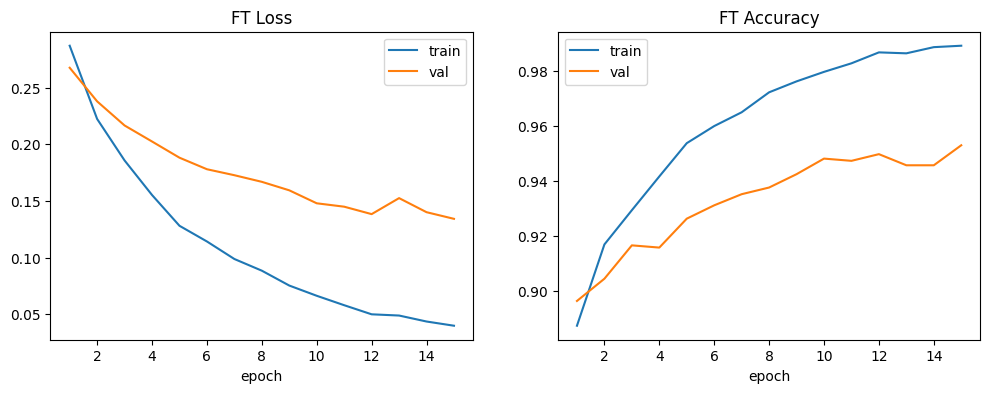

[FT] Synthetic test: acc 0.955 | loss 0.115
[FT] macro-F1: 0.955


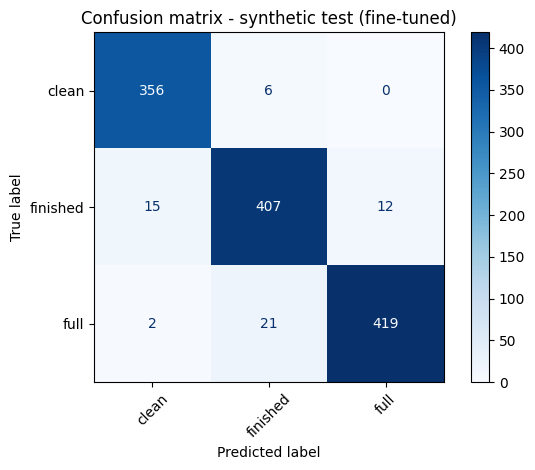

[FT] Binary (clear/do_not_clear) acc: 0.956


In [14]:
# Fine-tuned model: curves + confusion matrix + metrics (only if FT ran). Mirrors the linear-probe report.
if RUN_FINETUNE:
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score

    # --- training curves ---
    ep = range(1, len(ft_hist["tr_loss"]) + 1)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1); plt.plot(ep, ft_hist["tr_loss"], label="train"); plt.plot(ep, ft_hist["va_loss"], label="val")
    plt.title("FT Loss"); plt.xlabel("epoch"); plt.legend()
    plt.subplot(1, 2, 2); plt.plot(ep, ft_hist["tr_acc"], label="train"); plt.plot(ep, ft_hist["va_acc"], label="val")
    plt.title("FT Accuracy"); plt.xlabel("epoch"); plt.legend(); plt.show()

    # --- synthetic test + confusion matrix + macro-F1 ---
    ft_test_loss, ft_test_acc = run_epoch(model, test_loader, False)
    print(f"[FT] Synthetic test: acc {ft_test_acc:.3f} | loss {ft_test_loss:.3f}")
    y_true, y_pred = predict(model, test_loader)
    ft_f1 = f1_score(y_true, y_pred, average="macro")
    print("[FT] macro-F1:", round(ft_f1, 3))
    ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred), display_labels=CLASSES).plot(cmap="Blues", xticks_rotation=45)
    plt.title("Confusion matrix - synthetic test (fine-tuned)"); plt.tight_layout(); plt.show()

    # --- binary clear / do-not-clear accuracy ---
    to_bin = {i: utils.to_binary(c) for i, c in enumerate(CLASSES)}
    bt = [to_bin[t] for t in y_true]; bp = [to_bin[p] for p in y_pred]
    ft_bin = float(np.mean(np.array(bt) == np.array(bp)))
    print("[FT] Binary (clear/do_not_clear) acc:", round(ft_bin, 3))

    # --- W&B (ft_-labelled, so LP vs FT are comparable in one run) ---
    wlog({"macro_f1": float(ft_f1),
          **({"binary_acc": ft_bin} if ft_bin is not None else {})})
    if USE_WANDB:
        wandb.log({"confusion_matrix": wandb.plot.confusion_matrix(probs=None, y_true=y_true, preds=y_pred, class_names=CLASSES)})
else:
    print("RUN_FINETUNE is False - no FT report.")

## (Optional) Real-CCTV evaluation

Only runs if step 04 produced a labelled `data/real_test/`. Per CLAUDE.md the real photos are
calibration/inspiration - this is a *bonus sanity check*, not a primary metric.

/tmp/ipykernel_1621683/694199768.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  sd = torch.load(ckpt, map_location=device)


loaded resnet18_finetuned_best.pth | model classes: ['clean', 'finished', 'full'] | real folders: ['clean', 'finished', 'full']

=== Accuracy P1 (class): 95.6%   (43/45) ===
=== Accuracy (clear / do-not-clear rule): 95.6%   (43/45) ===

image                           | true_label | predicted_label | correct | confidence | true_rule    | predicted_rule
--------------------------------+------------+-----------------+---------+------------+--------------+---------------
צילום מסך 2026-06-29 223442.png | clean      | clean           | YES     | 0.998      | do_not_clear | do_not_clear  
צילום מסך 2026-06-29 223559.png | clean      | clean           | YES     | 0.997      | do_not_clear | do_not_clear  
צילום מסך 2026-06-30 014953.png | clean      | clean           | YES     | 1.0        | do_not_clear | do_not_clear  
צילום מסך 2026-06-30 015122.png | clean      | clean           | YES     | 1.0        | do_not_clear | do_not_clear  
צילום מסך 2026-06-30 015225.png | clean      | clean   

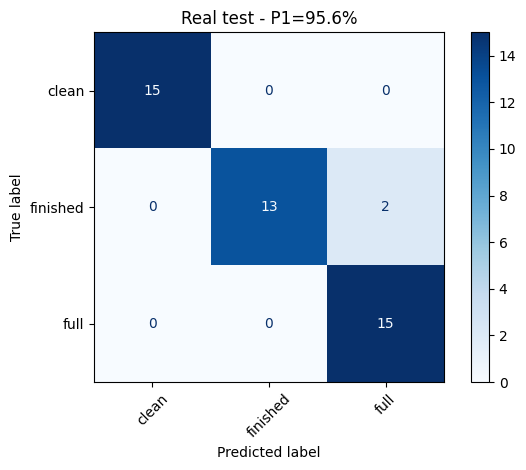

In [15]:
# --- Real-test evaluation + per-image report (STANDALONE; runs even after a kernel restart) ---
# Loads the trained model from results/, predicts every real image, prints accuracy P1, and writes an
# Excel-openable per-image table: true label vs. model estimate vs. the clear/do-not-clear rule.
import sys, csv, numpy as np, torch
from pathlib import Path
from torchvision import datasets, transforms
from torchvision.models import resnet18
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
for _c in (Path.cwd(), Path.cwd() / "code"):
    if (_c / "utils.py").exists() and str(_c) not in sys.path:
        sys.path.insert(0, str(_c)); break
import utils

device = "cuda" if torch.cuda.is_available() else "cpu"
real_test_dir = utils.DATA_DIR / "real_test"

if not (real_test_dir.is_dir() and any(real_test_dir.iterdir())):
    print("No labelled real_test/ at", real_test_dir, "- nothing to evaluate.")
else:
    # any input size is fine - Resize forces 224x224 (squashes non-square; swap to Resize(224)+CenterCrop(224) to avoid)
    tf = transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(),
                             transforms.Normalize([0.5] * 3, [0.5] * 3)])
    real_ds = datasets.ImageFolder(str(real_test_dir))   # no transform: apply tf per image so we keep the file paths

    # load best saved model (prefer fine-tuned, else frozen)
    ckpt = utils.RESULTS_DIR / "resnet18_finetuned_best.pth"
    if not ckpt.exists():
        ckpt = utils.RESULTS_DIR / "resnet18_frozen_best.pth"
    sd = torch.load(ckpt, map_location=device)
    model = resnet18(weights=None)
    model.fc = torch.nn.Linear(model.fc.in_features, sd["fc.weight"].shape[0])
    model.load_state_dict(sd); model.to(device).eval()

    # model output order = TRAINING classes (sorted Diff_DataSet folders) -> map predictions by NAME (robust)
    model_classes = sorted(d.name for d in utils.CLEAN_DIR.iterdir() if d.is_dir())
    print("loaded", ckpt.name, "| model classes:", model_classes, "| real folders:", real_ds.classes)

    rows, y_true, y_pred = [], [], []
    with torch.no_grad():
        for path, true_idx in real_ds.samples:
            x = tf(real_ds.loader(path)).unsqueeze(0).to(device)
            probs = model(x).softmax(1)[0].cpu().numpy()
            pred_idx = int(probs.argmax())
            true_name = real_ds.classes[true_idx]
            pred_name = model_classes[pred_idx] if pred_idx < len(model_classes) else str(pred_idx)
            rows.append({
                "image": Path(path).name,
                "true_label": true_name,
                "predicted_label": pred_name,
                "correct": "YES" if pred_name == true_name else "NO",
                "confidence": round(float(probs[pred_idx]), 3),
                "true_rule": utils.to_binary(true_name),
                "predicted_rule": utils.to_binary(pred_name) if pred_name in model_classes else "?",
            })
            y_true.append(true_name); y_pred.append(pred_name)

    n = len(rows)
    n_correct = sum(r["correct"] == "YES" for r in rows)
    n_rule = sum(r["true_rule"] == r["predicted_rule"] for r in rows)
    P1 = 100.0 * n_correct / n if n else 0.0
    P_rule = 100.0 * n_rule / n if n else 0.0
    print(f"\n=== Accuracy P1 (class): {P1:.1f}%   ({n_correct}/{n}) ===")
    print(f"=== Accuracy (clear / do-not-clear rule): {P_rule:.1f}%   ({n_rule}/{n}) ===\n")

    # per-image table to the console
    hdr = ["image", "true_label", "predicted_label", "correct", "confidence", "true_rule", "predicted_rule"]
    wid = {h: max([len(h)] + [len(str(r[h])) for r in rows]) for h in hdr}
    print(" | ".join(h.ljust(wid[h]) for h in hdr))
    print("-+-".join("-" * wid[h] for h in hdr))
    for r in rows:
        print(" | ".join(str(r[h]).ljust(wid[h]) for h in hdr))

    # Excel-openable CSV (utf-8-sig so Excel shows the Hebrew filenames correctly)
    out_csv = utils.RESULTS_DIR / "real_test_predictions.csv"
    utils.RESULTS_DIR.mkdir(parents=True, exist_ok=True)
    with open(out_csv, "w", newline="", encoding="utf-8-sig") as f:
        w = csv.DictWriter(f, fieldnames=hdr); w.writeheader(); w.writerows(rows)
    print(f"\nper-image table -> {out_csv}")

    # confusion matrix over the full model class set
    cm = confusion_matrix(y_true, y_pred, labels=model_classes)
    ConfusionMatrixDisplay(cm, display_labels=model_classes).plot(cmap="Blues", xticks_rotation=45)
    plt.title(f"Real test - P1={P1:.1f}%"); plt.tight_layout(); plt.show()

In [16]:
# Close the W&B run (if tracking was on)
if USE_WANDB:
    wandb.finish()

binary_acc,▁
epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
macro_f1,▁
test_acc,▁▄▅▅▆▇▇▇▇▇▇▇▇██
test_loss,█▆▅▅▄▃▃▃▂▂▂▁▂▁▁
train_acc,▁▃▄▅▆▆▆▇▇▇█████
train_loss,█▆▅▄▃▃▃▂▂▂▂▁▁▁▁
val_acc,▁▂▃▃▅▅▆▆▇▇▇█▇▇█
val_loss,█▆▅▅▄▃▃▃▂▂▂▁▂▁▁
binary_acc,0.95638
epoch,15
